# 🤖 Notebook 03 — Model Training & Evaluation

**Project:** Churn Platform  
**Goal:** Train, compare, tune, and persist the best churn prediction model.  
Production training logic lives in `src/models/train.py` and `src/models/evaluate.py`.

---
### Sections
1. Environment Setup
2. Data Loading & Train/Test Split
3. Baseline Models — Quick Comparison
4. Cross-Validation — Robust Estimation
5. Hyperparameter Tuning (XGBoost)
6. Final Model Evaluation
7. Feature Importance & SHAP Analysis
8. Threshold Calibration
9. Persist Best Model

## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import json
import joblib
import time

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE  = 42
CV_FOLDS      = 5

print('Environment ready.')

Environment ready.


## 2. Data Loading & Train/Test Split

In [2]:
X = pd.read_csv(PROCESSED_DIR / 'X.csv')
y = pd.read_csv(PROCESSED_DIR / 'y.csv').squeeze()

print(f'X: {X.shape}  |  y: {y.shape}')
print(f'Churn rate: {y.mean()*100:.1f}%')
print(f'Features  : {X.columns.tolist()}')

X: (7043, 30)  |  y: (7043,)
Churn rate: 26.5%
Features  : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'avg_monthly_spend', 'charge_gap', 'service_count', 'is_echeck_paperless', 'is_month_to_month', 'has_fiber', 'has_no_internet', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [3]:
# ── Stratified split — preserve class ratio ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test  churn rate: {y_test.mean()*100:.1f}%')

Train: (5634, 30)  |  Test: (1409, 30)
Train churn rate: 26.5%
Test  churn rate: 26.5%


In [4]:
# ── Apply SMOTE on training set only (prevent data leakage) ──────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE — Train shape: {X_train_sm.shape}')
print(f'Class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}')

After SMOTE — Train shape: (8278, 30)
Class distribution: {0: 4139, 1: 4139}


## 3. Baseline Models — Quick Comparison

In [5]:
# ── Define candidate models ───────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(n_neighbors=11, n_jobs=-1)
}

print(f'Comparing {len(MODELS)} models on SMOTE-augmented training data...')

Comparing 5 models on SMOTE-augmented training data...


In [6]:
# ── Evaluate all baseline models ─────────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Fit a model and return a dict of evaluation metrics."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    return {
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'Recall'    : recall_score(y_te, y_pred, zero_division=0),
        'F1'        : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
        'PR-AUC'    : average_precision_score(y_te, y_prob) if y_prob is not None else np.nan,
        'Train time': round(train_time, 2)
    }

results = {}
for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')
    results[name] = evaluate_model(model, X_train_sm, y_train_sm, X_test, y_test)
    print(f"F1={results[name]['F1']:.3f}  ROC-AUC={results[name]['ROC-AUC']:.3f}  ({results[name]['Train time']}s)")

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print('\n── Baseline Comparison ──')
print(results_df.round(4).to_string())

Training Logistic Regression... F1=0.614  ROC-AUC=0.839  (0.3s)
Training Random Forest... F1=0.601  ROC-AUC=0.828  (1.09s)
Training Gradient Boosting... F1=0.612  ROC-AUC=0.833  (4.49s)
Training XGBoost... F1=0.610  ROC-AUC=0.822  (0.71s)
Training KNN... F1=0.614  ROC-AUC=0.819  (0.0s)

── Baseline Comparison ──
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  Train time
Logistic Regression    0.7665     0.5470  0.7005  0.6143   0.8389  0.6587        0.30
Gradient Boosting      0.7566     0.5303  0.7246  0.6124   0.8332  0.6475        4.49
Random Forest          0.7715     0.5599  0.6497  0.6015   0.8283  0.6196        1.09
XGBoost                0.7402     0.5071  0.7647  0.6098   0.8221  0.6267        0.71
KNN                    0.7289     0.4935  0.8128  0.6141   0.8190  0.5625        0.00


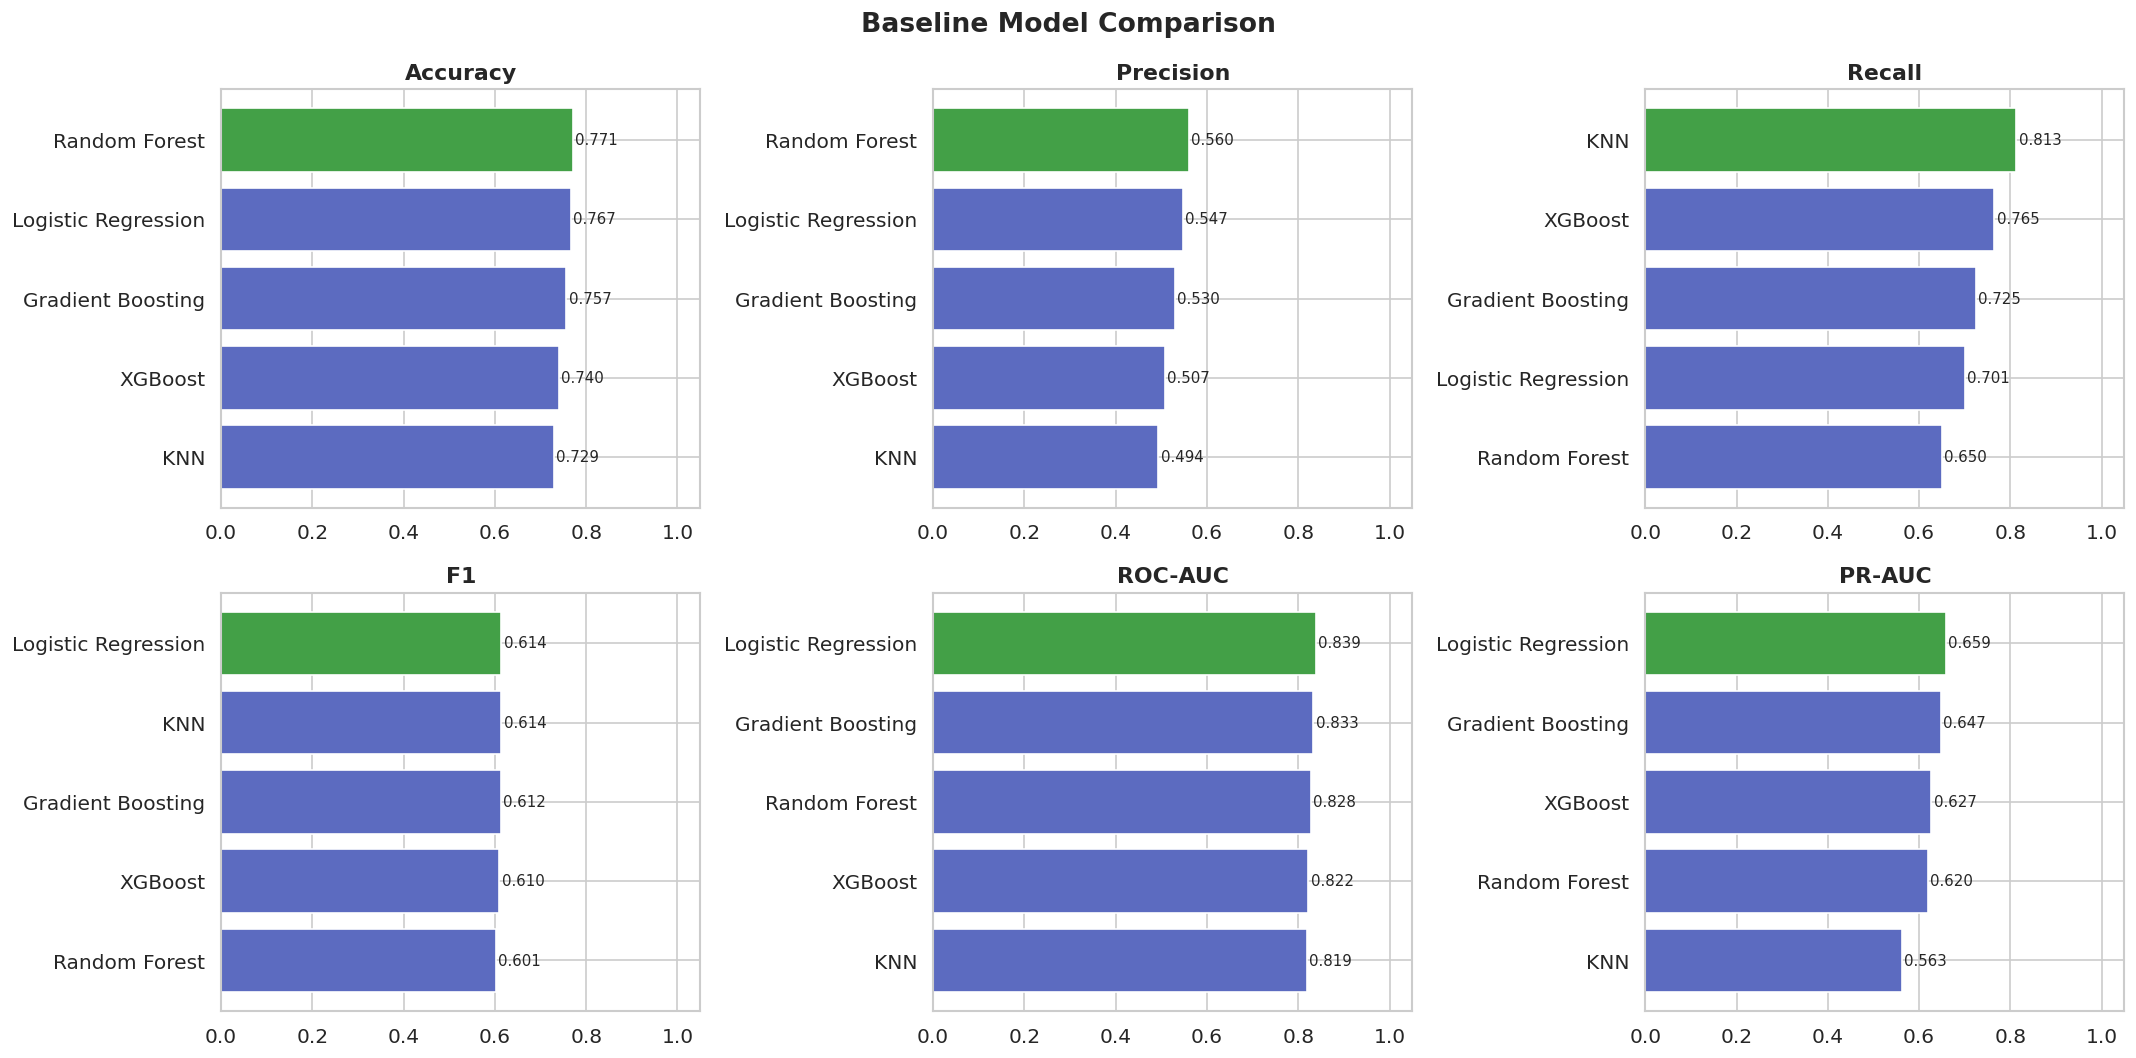

In [7]:
# ── Visualize baseline comparison ────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    data = results_df[metric].sort_values(ascending=True)
    colors = ['#43A047' if i == len(data)-1 else '#5C6BC0' for i in range(len(data))]
    bars = axes[i].barh(data.index, data.values, color=colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlim(0, 1.05)
    for bar, val in zip(bars, data.values):
        axes[i].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Cross-Validation — Robust Estimation

In [8]:
# ── Stratified K-Fold cross-validation on top 3 models ───────────────────────
TOP_MODELS = ['XGBoost', 'Random Forest', 'Gradient Boosting']
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name in TOP_MODELS:
    model = MODELS[name]
    cv_out = cross_validate(
        model, X_train_sm, y_train_sm,
        cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True,
        n_jobs=-1
    )
    cv_results[name] = cv_out
    print(f'{name:25s}  F1={cv_out["test_f1"].mean():.3f}±{cv_out["test_f1"].std():.3f}  '
          f'ROC-AUC={cv_out["test_roc_auc"].mean():.3f}±{cv_out["test_roc_auc"].std():.3f}')

XGBoost                    F1=0.841±0.005  ROC-AUC=0.915±0.006
Random Forest              F1=0.854±0.005  ROC-AUC=0.926±0.005
Gradient Boosting          F1=0.821±0.005  ROC-AUC=0.893±0.004


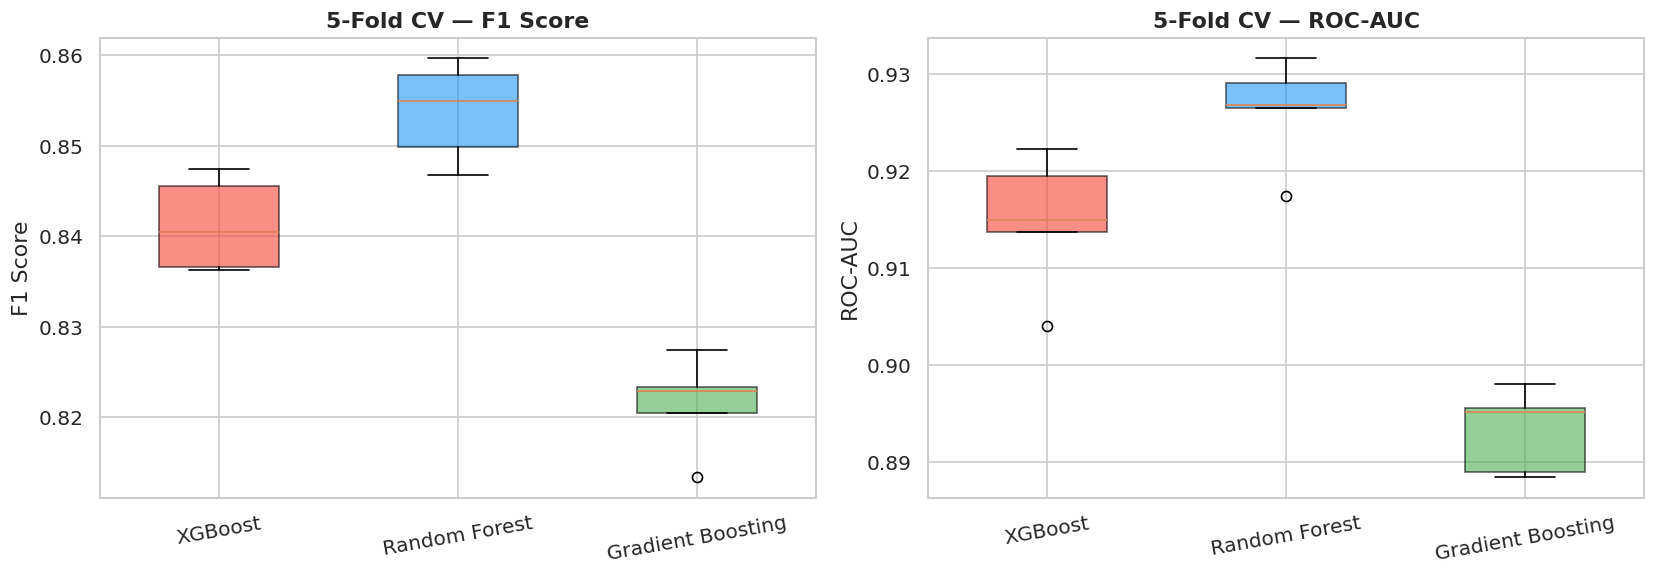

In [9]:
# ── CV score distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, title in [
    ('test_f1',      axes[0], 'F1 Score'),
    ('test_roc_auc', axes[1], 'ROC-AUC')
]:
    data_to_plot = [cv_results[name][metric] for name in TOP_MODELS]
    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5)
    colors_bp = ['#F44336', '#2196F3', '#4CAF50']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(TOP_MODELS, rotation=10)
    ax.set_title(f'{CV_FOLDS}-Fold CV — {title}', fontweight='bold')
    ax.set_ylabel(title)

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning (XGBoost)

In [10]:
# ── Randomized search over XGBoost hyperparameter space ─────────────────────
xgb_param_grid = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5],
    'reg_alpha'       : [0, 0.01, 0.1],
    'reg_lambda'      : [1, 1.5, 2],
}

xgb_base = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

print('Running RandomizedSearchCV (40 iterations × 5-fold)...')
t0 = time.time()
random_search.fit(X_train_sm, y_train_sm)
print(f'Done in {time.time()-t0:.1f}s')

print(f'\nBest ROC-AUC (CV): {random_search.best_score_:.4f}')
print(f'Best params:')
for k, v in random_search.best_params_.items():
    print(f'  {k:<22} = {v}')

Running RandomizedSearchCV (40 iterations × 5-fold)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Done in 12.2s

Best ROC-AUC (CV): 0.9195
Best params:
  subsample              = 0.8
  reg_lambda             = 2
  reg_alpha              = 0
  n_estimators           = 400
  min_child_weight       = 3
  max_depth              = 6
  learning_rate          = 0.1
  gamma                  = 0.1
  colsample_bytree       = 0.9


In [11]:
# ── Extract best model ────────────────────────────────────────────────────────
best_xgb = random_search.best_estimator_

# ── Test set evaluation ───────────────────────────────────────────────────────
y_pred_best  = best_xgb.predict(X_test)
y_prob_best  = best_xgb.predict_proba(X_test)[:, 1]

print('\n── Tuned XGBoost — Test Set Performance ──')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_best):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test, y_prob_best):.4f}')


── Tuned XGBoost — Test Set Performance ──
  Accuracy  : 0.7466
  Precision : 0.5154
  Recall    : 0.7594
  F1 Score  : 0.6141
  ROC-AUC   : 0.8191
  PR-AUC    : 0.6181


## 6. Final Model Evaluation


TP=284  FP=267  FN=90  TN=768
→ 90 churners missed (False Negatives) — business cost = revenue lost
→ 267 loyal customers incorrectly targeted (False Positives) — business cost = wasted retention spend


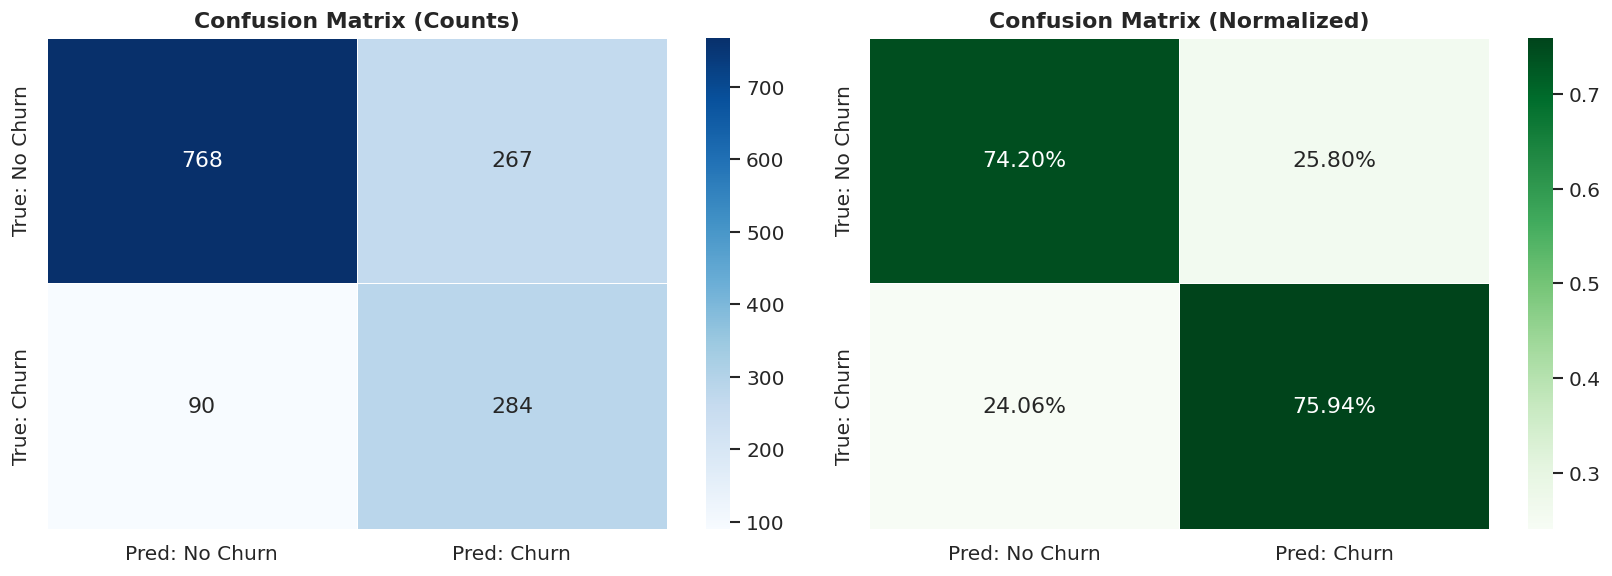

In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: No Churn', 'Pred: Churn'],
    yticklabels=['True: No Churn', 'True: Churn'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=['Pred: No Churn', 'Pred: Churn'],
    yticklabels=['True: No Churn', 'True: Churn'],
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

TN, FP, FN, TP = cm.ravel()
print(f'\nTP={TP}  FP={FP}  FN={FN}  TN={TN}')
print(f'→ {FN} churners missed (False Negatives) — business cost = revenue lost')
print(f'→ {FP} loyal customers incorrectly targeted (False Positives) — business cost = wasted retention spend')

plt.tight_layout()
plt.show()

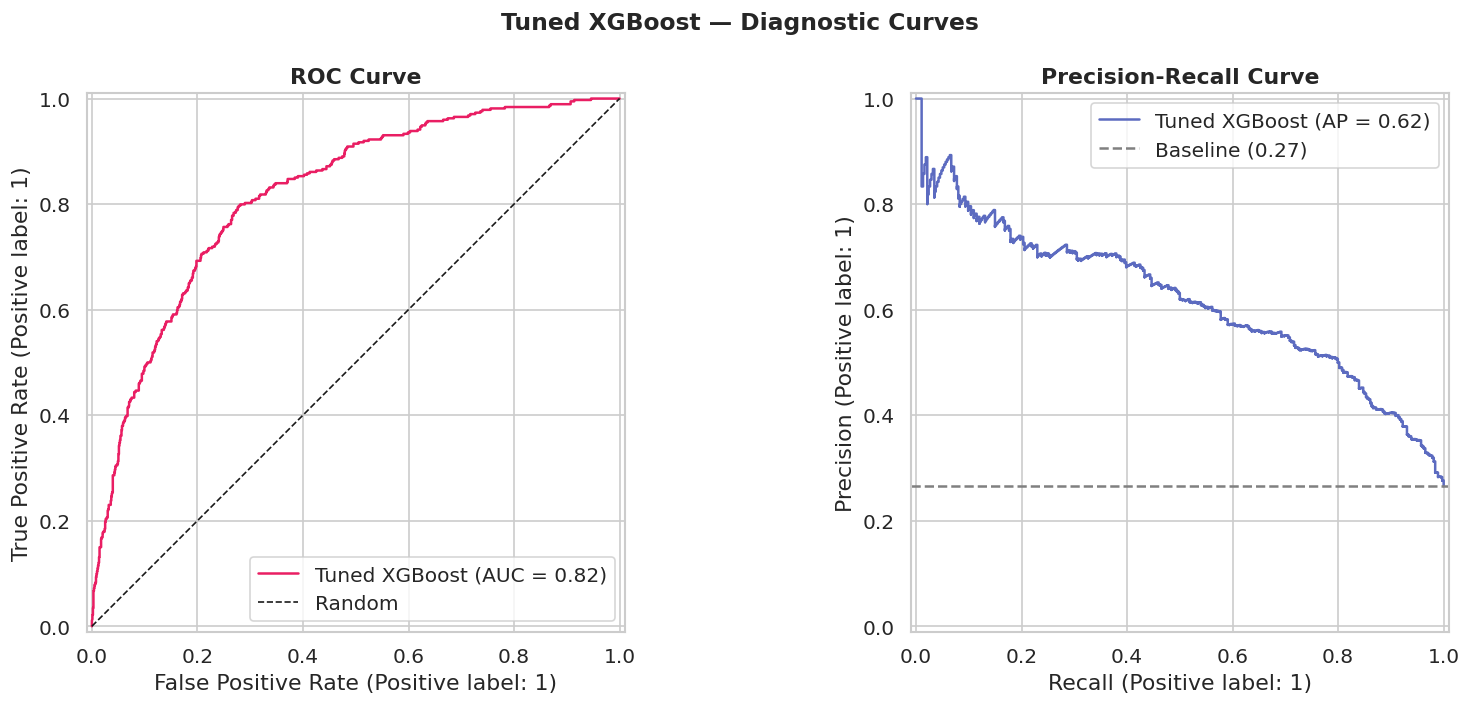

In [13]:
# ── ROC Curve & Precision-Recall Curve ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob_best,
    name='Tuned XGBoost',
    ax=axes[0],
    color='#E91E63'
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall (more informative for imbalanced datasets)
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_best,
    name='Tuned XGBoost',
    ax=axes[1],
    color='#5C6BC0'
)
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('Tuned XGBoost — Diagnostic Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Full classification report ────────────────────────────────────────────────
print('── Classification Report — Tuned XGBoost ──')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

── Classification Report — Tuned XGBoost ──
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



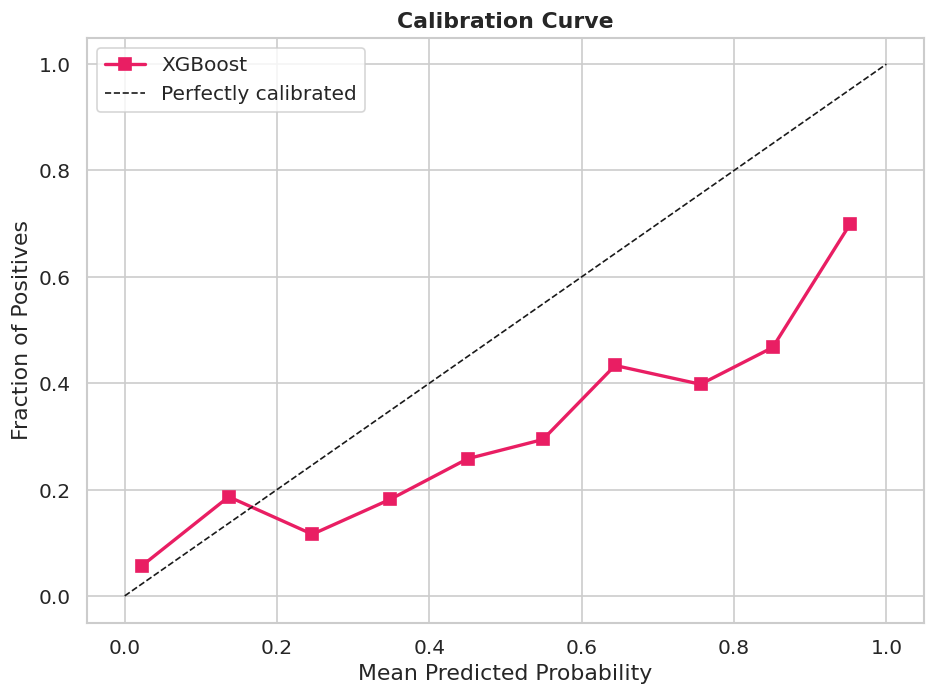

In [15]:
# ── Model calibration ─────────────────────────────────────────────────────────
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_best, n_bins=10
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_predicted_value, fraction_of_positives,
        's-', color='#E91E63', linewidth=2, markersize=7, label='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance & SHAP Analysis

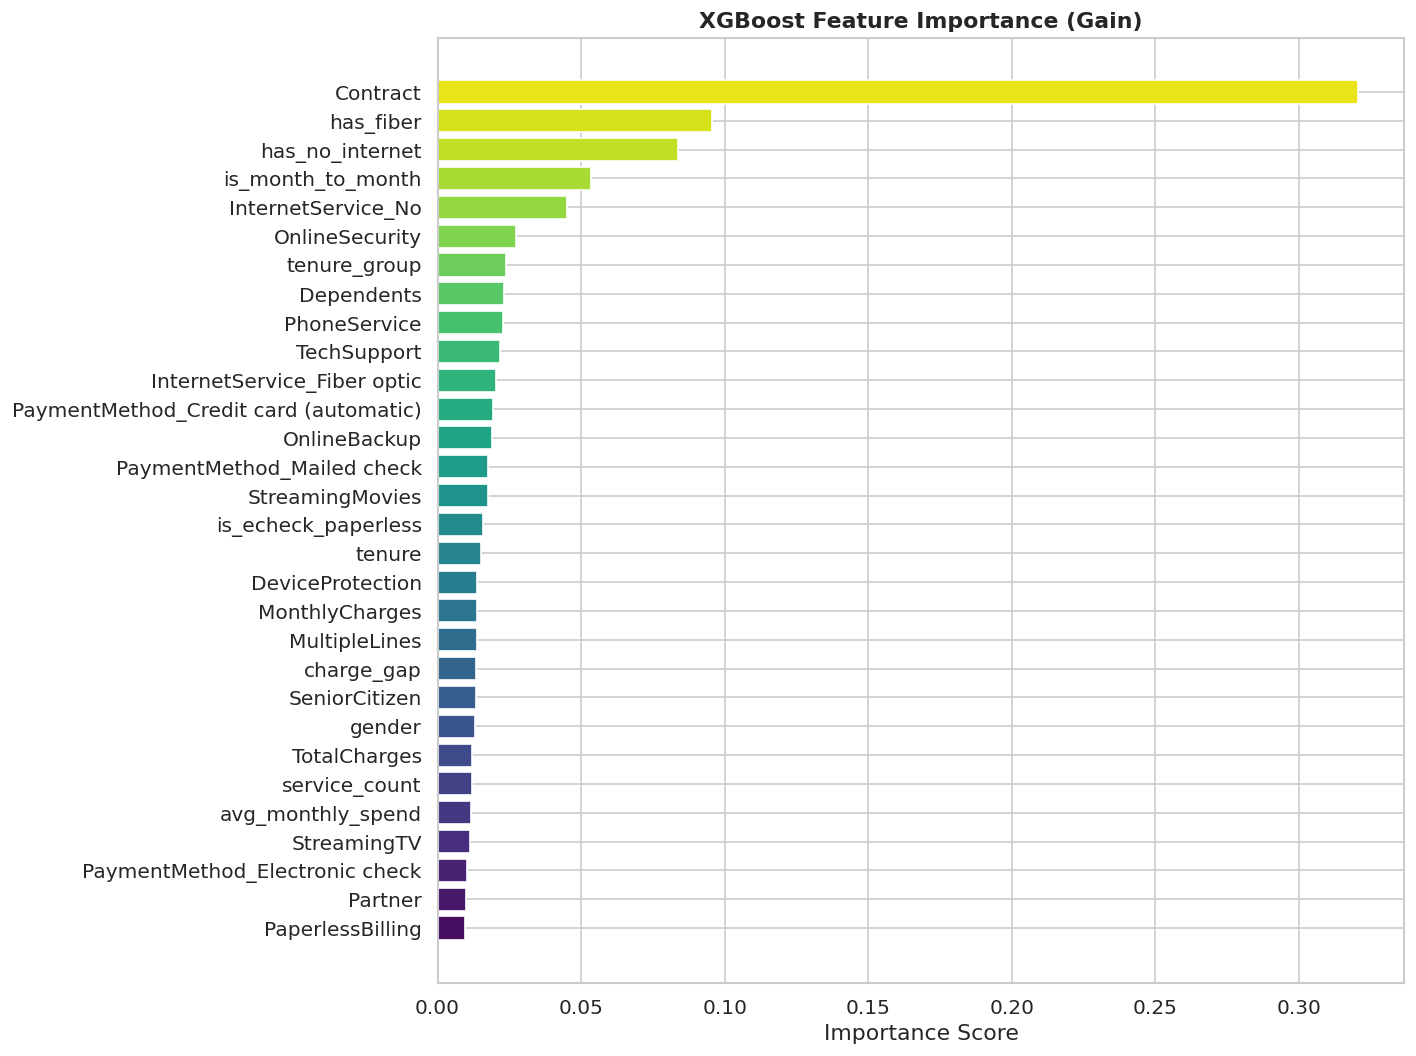

           Feature  Importance
          Contract    0.320768
         has_fiber    0.095697
   has_no_internet    0.083872
 is_month_to_month    0.053417
InternetService_No    0.045132
    OnlineSecurity    0.027221
      tenure_group    0.023706
        Dependents    0.023239
      PhoneService    0.022876
       TechSupport    0.021632


In [16]:
# ── Built-in XGBoost feature importance ──────────────────────────────────────
fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))
palette = sns.color_palette('viridis', len(fi))
bars = ax.barh(fi['Feature'], fi['Importance'], color=palette[::-1], edgecolor='white')
ax.set_title('XGBoost Feature Importance (Gain)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(fi.head(10).to_string(index=False))

In [17]:
# ── SHAP Analysis ─────────────────────────────────────────────────────────────
try:
    import shap

    explainer  = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_test)

    # Beeswarm (summary) plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, plot_type='violin', show=False)
    plt.title('SHAP Summary Plot — Feature Impact on Churn Probability', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    # Bar summary
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
    plt.title('Mean |SHAP| — Global Feature Importance', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    # Waterfall for a single high-risk customer
    high_risk_idx = np.argmax(y_prob_best)
    print(f'\nWaterfall plot for highest-risk customer (prob={y_prob_best[high_risk_idx]:.3f}):')
    shap_exp = shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx].values,
        feature_names=X_test.columns.tolist()
    )
    shap.waterfall_plot(shap_exp, max_display=15, show=True)

except ImportError:
    print('shap not installed. Run: pip install shap')
    print('Skipping SHAP analysis.')

shap not installed. Run: pip install shap
Skipping SHAP analysis.


## 8. Threshold Calibration

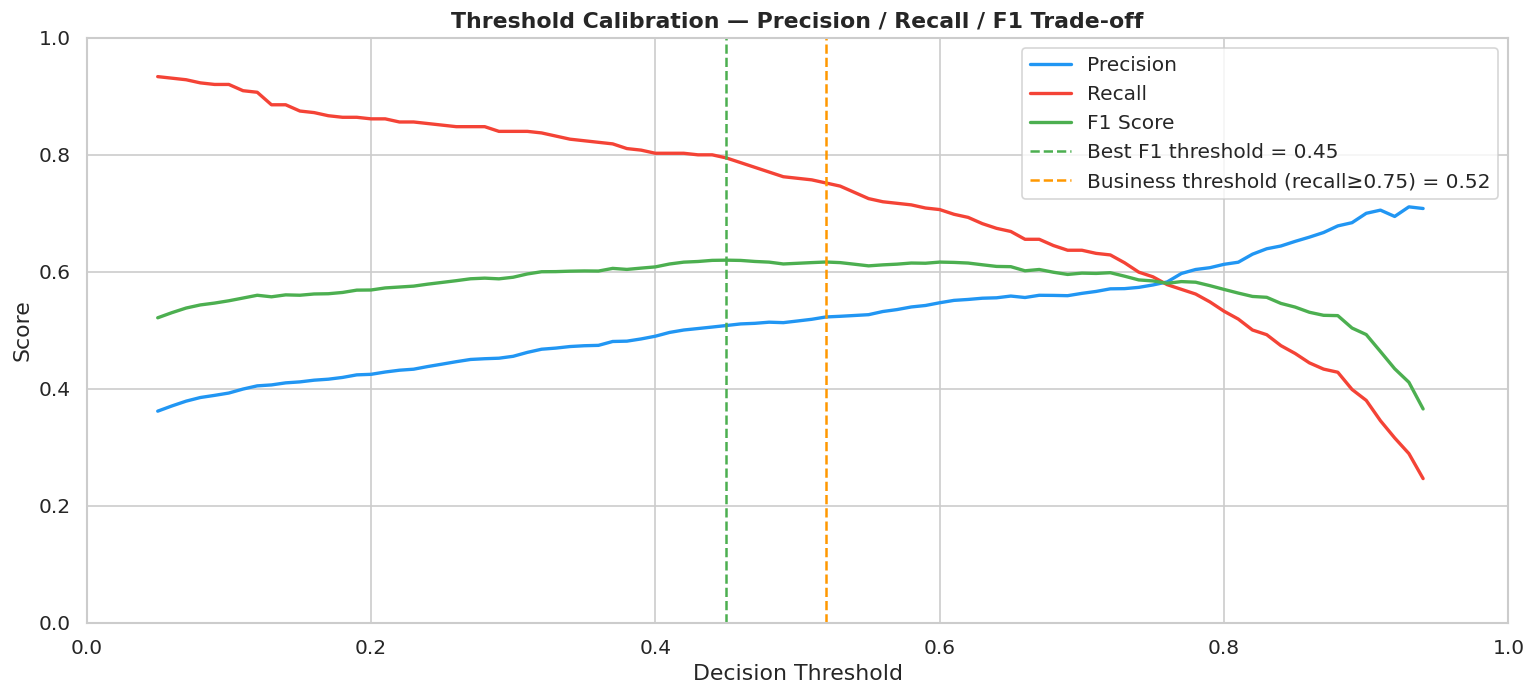

Default threshold  (0.5) → F1: 0.6141
Best F1 threshold (0.45) → F1: 0.6194
Business threshold (0.52) → Recall: 0.7513  Precision: 0.5223


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# Business context:
#   • Missing a churner (FN) is typically more costly than a false alarm (FP)
#   • Lowering the decision threshold → higher recall, lower precision
#   • We find the threshold that maximizes F1 AND a business-weighted score
# ──────────────────────────────────────────────────────────────────────────────

thresholds = np.arange(0.05, 0.95, 0.01)

thresh_metrics = []
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    thresh_metrics.append({
        'threshold' : round(t, 2),
        'precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'recall'    : recall_score(y_test, y_pred_t, zero_division=0),
        'f1'        : f1_score(y_test, y_pred_t, zero_division=0),
        'accuracy'  : accuracy_score(y_test, y_pred_t)
    })

thresh_df = pd.DataFrame(thresh_metrics)

# Optimal thresholds
best_f1_thresh     = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
# Business: we want recall ≥ 0.75 while maximising precision
high_recall_mask   = thresh_df['recall'] >= 0.75
best_biz_thresh    = thresh_df[high_recall_mask].loc[
    thresh_df[high_recall_mask]['precision'].idxmax(), 'threshold'
]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#2196F3', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#F44336', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  color='#4CAF50', linewidth=2)
ax.axvline(best_f1_thresh,  color='#4CAF50', linestyle='--', linewidth=1.5,
           label=f'Best F1 threshold = {best_f1_thresh}')
ax.axvline(best_biz_thresh, color='#FF9800', linestyle='--', linewidth=1.5,
           label=f'Business threshold (recall≥0.75) = {best_biz_thresh}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Calibration — Precision / Recall / F1 Trade-off', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Default threshold  (0.5) → F1: {thresh_df[thresh_df.threshold==0.5].f1.values[0]:.4f}')
print(f'Best F1 threshold ({best_f1_thresh}) → F1: {thresh_df[thresh_df.threshold==best_f1_thresh].f1.values[0]:.4f}')
print(f'Business threshold ({best_biz_thresh}) → Recall: {thresh_df[thresh_df.threshold==best_biz_thresh].recall.values[0]:.4f}  Precision: {thresh_df[thresh_df.threshold==best_biz_thresh].precision.values[0]:.4f}')

## 9. Persist Best Model

In [19]:
# ── Save model artifacts ─────────────────────────────────────────────────────
from datetime import datetime

version = datetime.now().strftime('%Y%m%d_%H%M')
model_path = MODELS_DIR / f'xgboost_churn_{version}.pkl'

joblib.dump(best_xgb, model_path)
joblib.dump(best_xgb, MODELS_DIR / 'best_model.pkl')   # latest alias

print(f'✅ Model saved → {model_path}')
print(f'✅ Model saved → {MODELS_DIR / "best_model.pkl"} (alias)')

# ── Save model metadata ───────────────────────────────────────────────────────
metadata = {
    'version'       : version,
    'model_type'    : 'XGBoostClassifier',
    'best_params'   : random_search.best_params_,
    'train_shape'   : list(X_train_sm.shape),
    'test_shape'    : list(X_test.shape),
    'test_metrics'  : {
        'accuracy'  : round(accuracy_score(y_test, y_pred_best),  4),
        'precision' : round(precision_score(y_test, y_pred_best), 4),
        'recall'    : round(recall_score(y_test, y_pred_best),    4),
        'f1'        : round(f1_score(y_test, y_pred_best),        4),
        'roc_auc'   : round(roc_auc_score(y_test, y_prob_best),   4),
        'pr_auc'    : round(average_precision_score(y_test, y_prob_best), 4)
    },
    'decision_threshold' : float(best_f1_thresh),
    'features'      : X.columns.tolist(),
    'smote_applied' : True,
    'timestamp'     : version
}

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Metadata saved → {MODELS_DIR / "model_metadata.json"}')
print('\n── Model Metadata ──')
print(json.dumps(metadata, indent=2))

✅ Model saved → ../models/xgboost_churn_20260807_0018.pkl
✅ Model saved → ../models/best_model.pkl (alias)
✅ Metadata saved → ../models/model_metadata.json

── Model Metadata ──
{
  "version": "20260807_0018",
  "model_type": "XGBoostClassifier",
  "best_params": {
    "subsample": 0.8,
    "reg_lambda": 2,
    "reg_alpha": 0,
    "n_estimators": 400,
    "min_child_weight": 3,
    "max_depth": 6,
    "learning_rate": 0.1,
    "gamma": 0.1,
    "colsample_bytree": 0.9
  },
  "train_shape": [
    8278,
    30
  ],
  "test_shape": [
    1409,
    30
  ],
  "test_metrics": {
    "accuracy": 0.7466,
    "precision": 0.5154,
    "recall": 0.7594,
    "f1": 0.6141,
    "roc_auc": 0.8191,
    "pr_auc": 0.6181
  },
  "decision_threshold": 0.45,
  "features": [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "Strea

In [20]:
# ── Final summary ─────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                  MODELING SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════╝

Best Model     : Tuned XGBoost (v{version})
Imbalance Fix  : SMOTE on training set only
Threshold      : {best_f1_thresh} (optimized for F1)

Test Set Metrics:
  Accuracy   = {metadata['test_metrics']['accuracy']:.4f}
  Precision  = {metadata['test_metrics']['precision']:.4f}
  Recall     = {metadata['test_metrics']['recall']:.4f}
  F1 Score   = {metadata['test_metrics']['f1']:.4f}
  ROC-AUC    = {metadata['test_metrics']['roc_auc']:.4f}
  PR-AUC     = {metadata['test_metrics']['pr_auc']:.4f}

Saved:
  models/best_model.pkl
  models/model_metadata.json
  models/standard_scaler.pkl
  models/ordinal_encoder_contract.pkl
  models/feature_names.json

Proceed to 04_business_insights.ipynb
""")


╔══════════════════════════════════════════════════════════════════╗
║                  MODELING SUMMARY                                ║
╚══════════════════════════════════════════════════════════════════╝

Best Model     : Tuned XGBoost (v20260807_0018)
Imbalance Fix  : SMOTE on training set only
Threshold      : 0.45 (optimized for F1)

Test Set Metrics:
  Accuracy   = 0.7466
  Precision  = 0.5154
  Recall     = 0.7594
  F1 Score   = 0.6141
  ROC-AUC    = 0.8191
  PR-AUC     = 0.6181

Saved:
  models/best_model.pkl
  models/model_metadata.json
  models/standard_scaler.pkl
  models/ordinal_encoder_contract.pkl
  models/feature_names.json

Proceed to 04_business_insights.ipynb

